# Decision walkthrough — PokerBot

> **Honesty banner.** The shipped public policy is a **hand-tuned heuristic blueprint**
> (preflop range tables distilled from public solver charts + flop-bucket postflop rules)
> plus eval7 Monte-Carlo equity and a **bounded** frequency overlay. MCCFR / CFR+ are the
> **intended** offline-trained replacement, *not* the running policy. Finals result:
> **qualified; finished top 40 of 64** — no podium implied. No bb/100, chip, or
> exploitability numbers appear in this notebook; those came from a private engine harness
> (see [`PROVENANCE.md`](../PROVENANCE.md)). Everything here runs in a clean clone with no
> `data/*.npz` and no engine.

## §1 — Setup

`decide()` needs neither the blueprint `.npz` files nor the engine clone.

In [1]:
%matplotlib inline
import sys
from pathlib import Path

def find_root(start: Path) -> Path:
    for cand in [start, *start.parents]:
        if (cand / "src" / "bot.py").is_file():
            return cand
    raise RuntimeError(f"repo root not found from {start}")

ROOT = find_root(Path.cwd())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print("repo root          :", ROOT.name)
print("data/*.npz present :", [p.name for p in sorted((ROOT/"data").glob("*.npz"))] or "none (gitignored, optional)")
print("engine needed?     : no — eval7 runs in-process; no ext/fullhouse-engine required")

from src.bot import decide
demo_state = {"type":"action_request","hand_id":"demo","street":"preflop","seat_to_act":3,
              "pot":150,"community_cards":[],"current_bet":100,"min_raise_to":200,"amount_owed":100,
              "can_check":False,"your_cards":["As","Ah"],"your_stack":10000,"your_bet_this_street":0,
              "players":[{"seat":i,"bot_id":f"s{i}","stack":10000,"state":"active","is_folded":False,
                          "is_all_in":False,"bet_this_street":0,"hole_cards":None} for i in range(6)],
              "action_log":[{"seat":0,"action":"small_blind","amount":50},
                            {"seat":1,"action":"big_blind","amount":100}],
              "match_action_log":[]}
print("decide() on AA preflop ->", decide(demo_state))

repo root          : PokerBot
data/*.npz present : none (gitignored, optional)
engine needed?     : no — eval7 runs in-process; no ext/fullhouse-engine required
decide() on AA preflop -> {'action': 'raise', 'amount': 300}


## §2 — The decision pipeline

Each `decide()` call flows through: **legalize** the action space → consult the **blueprint**
(preflop range tables / postflop equity) → fold in the bounded **overlay** deviation → pick a
**sizing**. Below, four spots show the intermediate values, not just the final action.

In [2]:
from src.bot import _infer_position, _action_sequence_preflop
from src.preflop_lookup import lookup
from src.equity import canonical_hand, hand_strength
from src.opponent_model import get_model

def show(label, state):
    print("=" * 72)
    print(label)
    decision = decide(state)
    if state["street"] == "preflop":
        hand = canonical_hand(state["your_cards"])
        pos = _infer_position(state)
        seq = _action_sequence_preflop(state)
        tag = lookup(pos, hand, seq).get("tag")
        print(f"  legalize : to_call={state['amount_owed']}  can_check={state['can_check']}")
        print(f"  blueprint: hand={hand}  position={pos}  action_seq={seq}  -> tag={tag!r}")
    else:
        eq = hand_strength(state["your_cards"], state["community_cards"])
        print(f"  legalize : to_call={state['amount_owed']} on {' '.join(state['community_cards'])}")
        print(f"  equity   : hand_strength vs random = {eq:.3f}")
    shift = get_model().exploit_shift(1)
    nonzero = sum(1 for v in shift.values() if v)
    print(f"  overlay  : exploit_shift nonzero knobs = {nonzero}  (0 = neutral; clean clone has no priors)")
    print(f"  sizing -> : {decision}")

def players(n=6):
    return [{"seat":i,"bot_id":f"s{i}","stack":10000,"state":"active","is_folded":False,
             "is_all_in":False,"bet_this_street":0,"hole_cards":None} for i in range(n)]

def postflop(hero, board, bet, street):
    return {"type":"action_request","hand_id":"nbp","street":street,"seat_to_act":0,"pot":1000+bet,
            "community_cards":board,"current_bet":bet,"min_raise_to":bet*2,"amount_owed":bet,
            "can_check":False,"your_cards":list(hero),"your_stack":9000,"your_bet_this_street":0,
            "players":[{"seat":0,"bot_id":"s0","stack":9000,"state":"active","is_folded":False,
                        "is_all_in":False,"bet_this_street":0,"hole_cards":None},
                       {"seat":1,"bot_id":"s1","stack":9000,"state":"active","is_folded":False,
                        "is_all_in":False,"bet_this_street":bet,"hole_cards":None}],
            "action_log":[{"seat":1,"action":"raise","amount":bet}],"match_action_log":[]}

blinds = [{"seat":0,"action":"small_blind","amount":50},{"seat":1,"action":"big_blind","amount":100}]

show("Spot 1 — BTN, folded to the button, AQo (blueprint opens)",
     {"type":"action_request","hand_id":"nb1","street":"preflop","seat_to_act":5,"pot":150,
      "community_cards":[],"current_bet":100,"min_raise_to":200,"amount_owed":100,"can_check":False,
      "your_cards":["Ad","Qs"],"your_stack":10000,"your_bet_this_street":0,"players":players(),
      "action_log":blinds + [{"seat":2,"action":"fold"},{"seat":3,"action":"fold"},{"seat":4,"action":"fold"}],
      "match_action_log":[]})

show("Spot 2 — UTG, 72o, first to act (blueprint folds)",
     {"type":"action_request","hand_id":"nb2","street":"preflop","seat_to_act":2,"pot":150,
      "community_cards":[],"current_bet":100,"min_raise_to":200,"amount_owed":100,"can_check":False,
      "your_cards":["7d","2s"],"your_stack":10000,"your_bet_this_street":0,"players":players(),
      "action_log":blinds,"match_action_log":[]})

show("Spot 3 — flop, top set 777 on A K 7 facing a pot bet (value raise)",
     postflop(["7h","7d"], ["Ac","Kd","7s"], 700, "flop"))

show("Spot 4 — river, underpair 88 facing a pot bet: a bluff-catcher the bot folds",
     postflop(["8h","8c"], ["Ac","Kh","7s","2d","Qc"], 700, "river"))

Spot 1 — BTN, folded to the button, AQo (blueprint opens)
  legalize : to_call=100  can_check=False
  blueprint: hand=AQo  position=BTN  action_seq=('fold', 'fold', 'fold')  -> tag='open'
  overlay  : exploit_shift nonzero knobs = 0  (0 = neutral; clean clone has no priors)
  sizing -> : {'action': 'raise', 'amount': 250}
Spot 2 — UTG, 72o, first to act (blueprint folds)
  legalize : to_call=100  can_check=False
  blueprint: hand=72o  position=UTG  action_seq=()  -> tag='fold'
  overlay  : exploit_shift nonzero knobs = 0  (0 = neutral; clean clone has no priors)
  sizing -> : {'action': 'fold'}
Spot 3 — flop, top set 777 on A K 7 facing a pot bet (value raise)
  legalize : to_call=700 on Ac Kd 7s
  equity   : hand_strength vs random = 0.955
  overlay  : exploit_shift nonzero knobs = 0  (0 = neutral; clean clone has no priors)
  sizing -> : {'action': 'raise', 'amount': 1822}
Spot 4 — river, underpair 88 facing a pot bet: a bluff-catcher the bot folds
  legalize : to_call=700 on Ac Kh 7

## §3 — The bounded overlay clamps

The overlay's deviation is capped so a worst-case counter-exploit stays small. In a clean
clone there are no field priors, so the live overlay is **neutral** (all-zero shifts). To
*show the clamp working*, we inject a deliberately out-of-bound prior table and confirm every
emitted shift is pulled into the ±0.20 band — the same contract `tests/unit/test_overlay_clamp.py`
property-tests.

field priors loaded: False
warm-seat shift (no priors): {'widen_open': 0.0, 'cbet_bluff_more': 0.0, 'value_thinner': 0.0, 'bluff_catch_less': 0.0, 'tighten_open': 0.0, 'fold_to_pressure_less': 0.0, 'value_widen_vs_aggro': 0.0}
              widen_open: injected -0.90  ->  emitted -0.200
         cbet_bluff_more: injected -0.40  ->  emitted -0.200
           value_thinner: injected -0.20  ->  emitted -0.200
        bluff_catch_less: injected +0.00  ->  emitted +0.000
            tighten_open: injected +0.20  ->  emitted +0.200
   fold_to_pressure_less: injected +0.40  ->  emitted +0.200
    value_widen_vs_aggro: injected +0.90  ->  emitted +0.200


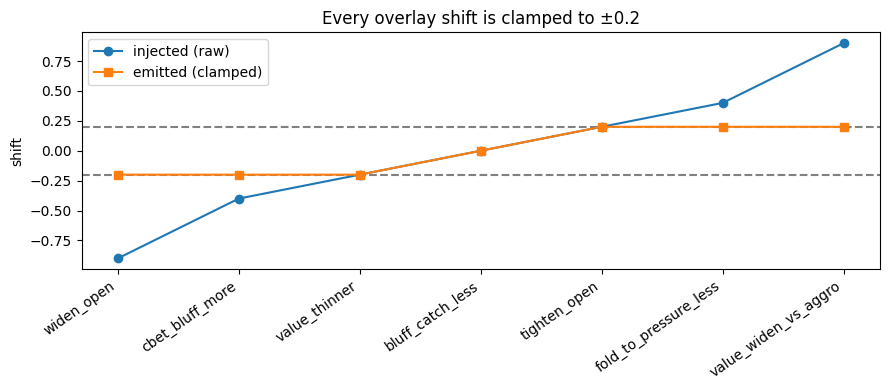

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from src import opponent_model as om
from src.opponent_model import OpponentModel, SHIFT_KEYS, MAX_DEVIATION_PP, WARMUP_HANDS

# 1) live overlay is neutral in a clean clone (no field_priors.npz)
print("field priors loaded:", om._FIELD_PRIORS is not None)
warm = OpponentModel(); warm._counts[1]["hands"] = WARMUP_HANDS
print("warm-seat shift (no priors):", warm.exploit_shift(1))

# 2) inject an OUT-OF-BOUND prior table and watch the clamp
def fake_priors(row):
    feats = ("vpip","pfr","af","fold_to_cbet")
    return {"feature_names":feats,"cluster_names":("c0",),
            "cluster_centroids":np.zeros((1,4),dtype=np.float32),
            "cluster_scales":np.ones((4,),dtype=np.float32),
            "shift_by_cluster":np.array([row],dtype=np.float32)}

raw = [-0.90, -0.40, -0.20, 0.00, 0.20, 0.40, 0.90]
om._FIELD_PRIORS = fake_priors(raw)
warm2 = OpponentModel(); warm2._counts[1]["hands"] = WARMUP_HANDS
clamped = warm2.exploit_shift(1)
om._FIELD_PRIORS = None  # restore clean-clone state

for k, r in zip(SHIFT_KEYS, raw):
    print(f"  {k:>22}: injected {r:+.2f}  ->  emitted {clamped[k]:+.3f}")

fig, ax = plt.subplots(figsize=(9, 4))
ax.axhline(MAX_DEVIATION_PP, ls="--", color="gray"); ax.axhline(-MAX_DEVIATION_PP, ls="--", color="gray")
ax.plot(range(len(SHIFT_KEYS)), raw, "o-", label="injected (raw)")
ax.plot(range(len(SHIFT_KEYS)), [clamped[k] for k in SHIFT_KEYS], "s-", label="emitted (clamped)")
ax.set_xticks(range(len(SHIFT_KEYS))); ax.set_xticklabels(SHIFT_KEYS, rotation=35, ha="right")
ax.set_ylabel("shift"); ax.set_title(f"Every overlay shift is clamped to ±{MAX_DEVIATION_PP}")
ax.legend(); fig.tight_layout(); plt.show()

## §4 — Preflop RFI ranges

Rendered straight from the `src.ranges` frozensets the bot uses (`tools/plot_preflop_heatmap.py`).
Pairs on the diagonal, suited above, offsuit below; the range widens UTG → BTN.

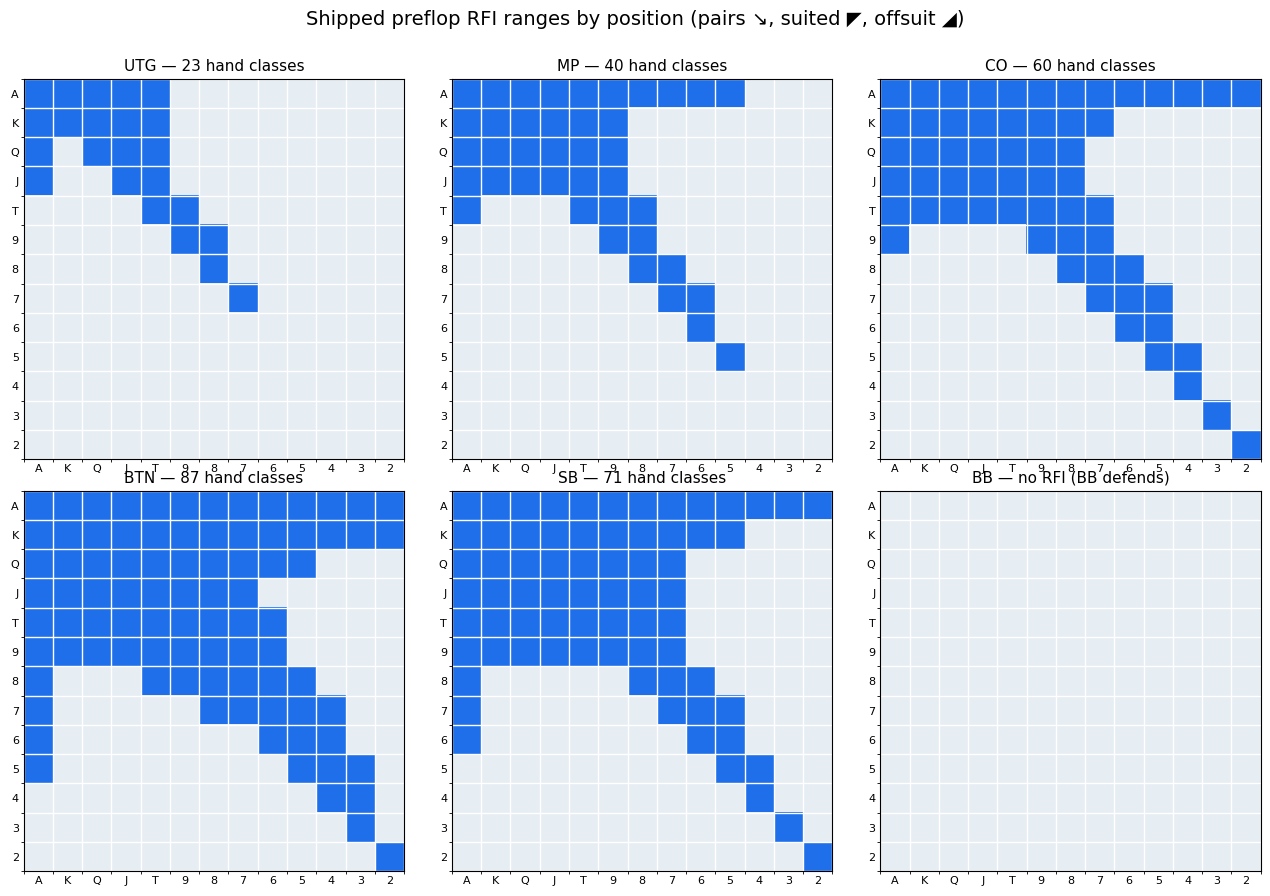

In [4]:
from tools.plot_preflop_heatmap import render
import matplotlib.pyplot as plt
render(out_path=None)  # build the figure from src.ranges; does not overwrite the committed PNG
plt.show()

## §5 — Monte-Carlo equity vs an exact baseline

On the turn the remaining board is small enough to **enumerate** exactly, giving ground truth
to check the MC estimator against. The estimate converges to the enumerated value as trials grow
(`tools/equity_study.py`).

exact (enumeration): 0.1570
  MC(   50): 0.2000   |err|=0.0430
  MC(  100): 0.2000   |err|=0.0430
  MC(  300): 0.1467   |err|=0.0104
  MC( 1000): 0.1390   |err|=0.0180
  MC( 3000): 0.1507   |err|=0.0064
  MC(10000): 0.1577   |err|=0.0007


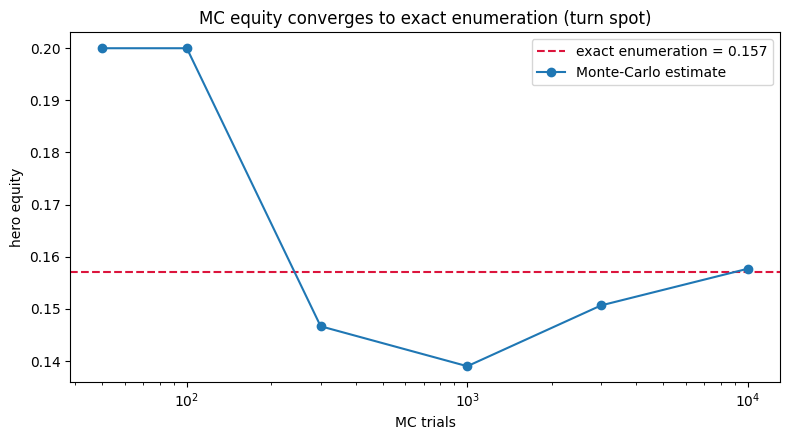

In [5]:
from tools.equity_study import convergence_sweep
import matplotlib.pyplot as plt

hero, board = ["Ah","Kd"], ["Qs","Jc","2d","7h"]
villain_range = ["QJ","TT","AQ","KK","99"]
trials, mc, exact = convergence_sweep(hero, board, villain_range, (50,100,300,1000,3000,10000))
print(f"exact (enumeration): {exact:.4f}")
for t, m in zip(trials, mc):
    print(f"  MC({t:>5}): {m:.4f}   |err|={abs(m-exact):.4f}")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.axhline(exact, color="crimson", ls="--", label=f"exact enumeration = {exact:.3f}")
ax.plot(trials, mc, "o-", label="Monte-Carlo estimate")
ax.set_xscale("log"); ax.set_xlabel("MC trials"); ax.set_ylabel("hero equity")
ax.set_title("MC equity converges to exact enumeration (turn spot)"); ax.legend()
fig.tight_layout()
fig.savefig(ROOT / "notebooks" / "figures" / "equity_convergence.png", dpi=150)
plt.show()

## §6 — Limitations & provenance

- The bot plays a tight, polarized line and **over-folds marginal hands under sustained postflop
  pressure** (Spot 4 above). That tendency is quantified as decision frequencies — never EV — in
  [`docs/results/overfold-postmortem.md`](../docs/results/overfold-postmortem.md)
  (`tools/overfold_probe.py`).
- Widening the calling range is the natural next revision, but it changes the strategy *shape* and
  reopens the full verification surface, so it was deferred rather than hot-patched into a frozen
  submission.
- bb/100 benchmarks, the LBR exploitability caps, and the variance figure are **private engine
  harness** numbers, not reproduced here. [`PROVENANCE.md`](../PROVENANCE.md) maps every claim to
  its source.